In [172]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_final_annot.h5ad')

In [3]:
adata_sub = adata[~adata.obs['normal'].isin(['AN','DN'])]

In [4]:
tcr = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')

In [179]:
tcr[tcr.obs['timepoint'] == 'F2'].obs[['progression','patient']].drop_duplicates()['progression'].value_counts()

Slow    21
Fast     7
Name: progression, dtype: int64

In [17]:
progression_dict = pd.Series(tcr.obs['progression'].values, index=tcr.obs['sample_x']).to_dict()

In [52]:
her2_neg = pd.read_excel('/home/jupyter/data/ge_korea/raw_data/CAPOX-Pem_Patient_withTCGA.xlsx',sheet_name='HER2 Negative')
her2_neg = her2_neg[['Subject No','PFS','PD 0= no progression, 1= progression']].dropna()

In [53]:
her2_pos = pd.read_excel('/home/jupyter/data/ge_korea/raw_data/CAPOX-Pem_Patient_withTCGA.xlsx',sheet_name='HER2 Positive')
her2_pos = pd.concat([her2_pos[['Subject No']],
           pd.DataFrame({'PFS' : [314,314,82,124]}),
           her2_pos[['PD 0= no progression, 1= progression']]],axis=1)

In [62]:
meta = pd.concat([her2_neg,her2_pos]).reset_index(drop=True).sort_values('Subject No')

In [63]:
meta_b = meta.copy()
meta_b['Subject No'] = [i+'_B' for i in meta_b['Subject No']]

meta_f1 = meta.copy()
meta_f1['Subject No'] = [i+'_F1' for i in meta_f1['Subject No']]

meta_f2 = meta.copy()
meta_f2['Subject No'] = [i+'_F2' for i in meta_f2['Subject No']]

meta = pd.concat([meta_b,meta_f1,meta_f2])

In [68]:
meta.index = meta['Subject No']

In [65]:
all_counts = adata_sub.obs[['annot_final','sample']].value_counts().reset_index().pivot(
    columns='annot_final',index='sample',values=0).fillna(0)
all_props = all_counts.div(all_counts.sum(axis=1),axis=0)
all_props['Progression'] = all_props.index.map(progression_dict).astype(str)
all_props = all_props.sort_values('Progression')
all_props['Timepoint'] = [i.split('_')[1] for i in all_props.index]
all_props['Progression Timepoint'] = all_props['Progression'].astype(str) + ' ' + all_props['Timepoint'].astype(str)

In [71]:
all_props['PFS'] = all_props.index.map(meta['PFS'].to_dict())

In [73]:
all_props['Censored PFS'] = all_props.index.map(meta['PD 0= no progression, 1= progression'].to_dict())

In [149]:
meta['PFS']

Subject No
E01_B      85.0
E02_B     121.0
E03_B     119.0
E04_B     549.0
E05_B     202.0
          ...  
E43_F2     82.0
E44_F2    162.0
E45_F2    124.0
E46_F2    219.0
E47_F2    217.0
Name: PFS, Length: 141, dtype: float64

In [81]:
all_props[all_props['B'] < all_props['B'].median()]

annot_final,B,C1QC Macrophage,CD4 T naive/early memory Cell,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 T naive/early memory Cell,CD8 Tem Cell,CD14 Monocyte,Capillary Endothelial,Epithelial,...,cDC2,gd T Cell,iCAF,mregDC,pDC,Progression,Timepoint,Progression Timepoint,PFS,Censored PFS
sample,,,,,,,,,,,,,,,,,,,,,
E25_F2,0.001449,0.020580,0.009565,0.026667,0.004638,0.001739,0.001739,0.027826,0.001739,0.715652,...,0.012174,0.019710,0.002029,0.005217,0.001739,Fast,F2,Fast F2,122.0,1.0
E34_B,0.000000,0.004361,0.001246,0.003115,0.013707,0.000000,0.000623,0.001869,0.012150,0.922741,...,0.001869,0.000000,0.002181,0.001246,0.000000,Fast,B,Fast B,94.0,1.0
E27_F2,0.000000,0.000000,0.003160,0.001580,0.031596,0.000000,0.031596,0.012638,0.015798,0.816746,...,0.000000,0.014218,0.004739,0.000000,0.000000,Fast,F2,Fast F2,160.0,1.0
E30_F1,0.000283,0.038549,0.071995,0.003401,0.002551,0.005385,0.064909,0.002834,0.026644,0.361111,...,0.030045,0.006236,0.083333,0.000850,0.000000,Fast,F1,Fast F1,124.0,1.0
E30_F2,0.000992,0.009921,0.016617,0.000496,0.012897,0.003472,0.204861,0.001984,0.017609,0.268601,...,0.004960,0.002232,0.263393,0.000000,0.000000,Fast,F2,Fast F2,124.0,1.0
E31_B,0.002409,0.025125,0.054208,0.010669,0.001721,0.008088,0.059714,0.005163,0.017037,0.524867,...,0.009121,0.003270,0.039064,0.001377,0.000516,Fast,B,Fast B,165.0,1.0
E19_F1,0.013149,0.020761,0.041522,0.014533,0.002076,0.011073,0.062976,0.005536,0.007612,0.428374,...,0.006228,0.004844,0.033218,0.000000,0.000000,Fast,F1,Fast F1,103.0,1.0
E31_F1,0.000714,0.004639,0.015165,0.010705,0.003747,0.002676,0.015522,0.002855,0.012667,0.784835,...,0.002855,0.004282,0.002676,0.000535,0.000357,Fast,F1,Fast F1,165.0,1.0
E31_F2,0.000414,0.006209,0.006209,0.001656,0.001656,0.006002,0.007243,0.003932,0.000207,0.921565,...,0.001449,0.002483,0.000828,0.000414,0.000207,Fast,F2,Fast F2,165.0,1.0


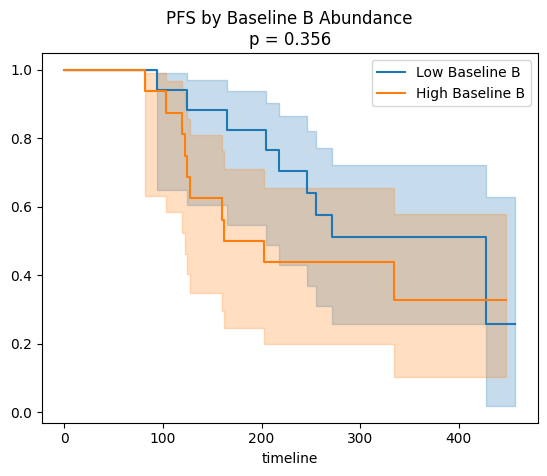

In [114]:
from lifelines import KaplanMeierFitter

temp_props = all_props[all_props['Timepoint'] == 'B']

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

T_A = temp_props[temp_props['B'] <= temp_props['B'].median()]['PFS']
E_A = temp_props[temp_props['B'] <= temp_props['B'].median()]['Censored PFS']
kmf_A.fit(T_A, E_A, label='Low Baseline B')
ax = kmf_A.plot_survival_function()

T_B = temp_props[temp_props['B'] > temp_props['B'].median()]['PFS']
E_B = temp_props[temp_props['B'] > temp_props['B'].median()]['Censored PFS']
kmf_B.fit(T_B, E_B, label='High Baseline B')
kmf_B.plot_survival_function(ax=ax)

results = logrank_test(
    durations_A=T_A,
    durations_B=T_B,
    event_observed_A=E_A,
    event_observed_B=E_B
)

plt.title(f"PFS by Baseline B Abundance\np = {round(results.p_value,3)}")
plt.show()

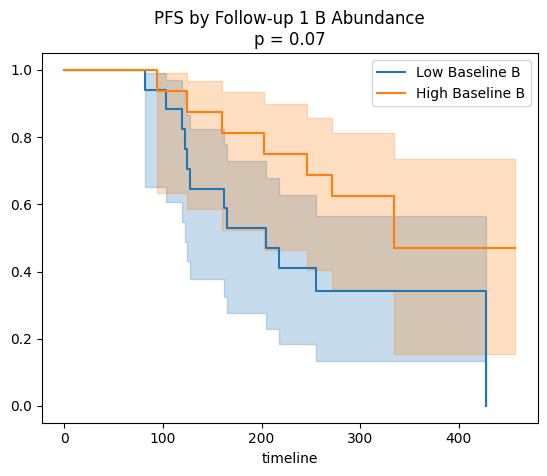

In [113]:
from lifelines import KaplanMeierFitter

temp_props = all_props[all_props['Timepoint'] == 'F1']

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

T_A = temp_props[temp_props['B'] <= temp_props['B'].median()]['PFS']
E_A = temp_props[temp_props['B'] <= temp_props['B'].median()]['Censored PFS']
kmf_A.fit(T_A, E_A, label='Low Baseline B')
ax = kmf_A.plot_survival_function()

T_B = temp_props[temp_props['B'] > temp_props['B'].median()]['PFS']
E_B = temp_props[temp_props['B'] > temp_props['B'].median()]['Censored PFS']
kmf_B.fit(T_B, E_B, label='High Baseline B')
kmf_B.plot_survival_function(ax=ax)

results = logrank_test(
    durations_A=T_A,
    durations_B=T_B,
    event_observed_A=E_A,
    event_observed_B=E_B
)

plt.title(f"PFS by Follow-up 1 B Abundance\np = {round(results.p_value,3)}")
plt.show()

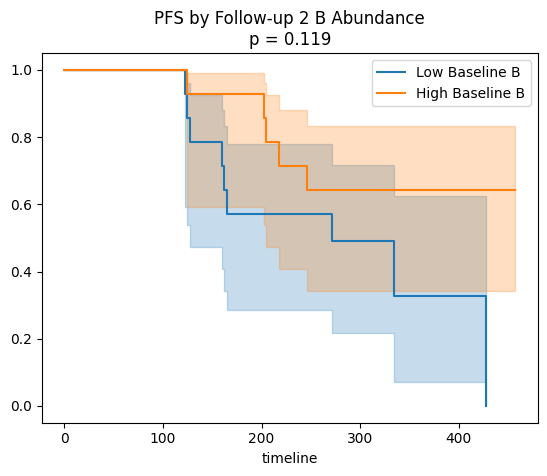

In [112]:
from lifelines import KaplanMeierFitter

temp_props = all_props[all_props['Timepoint'] == 'F2']

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

T_A = temp_props[temp_props['B'] <= temp_props['B'].median()]['PFS']
E_A = temp_props[temp_props['B'] <= temp_props['B'].median()]['Censored PFS']
kmf_A.fit(T_A, E_A, label='Low Baseline B')
ax = kmf_A.plot_survival_function()

T_B = temp_props[temp_props['B'] > temp_props['B'].median()]['PFS']
E_B = temp_props[temp_props['B'] > temp_props['B'].median()]['Censored PFS']
kmf_B.fit(T_B, E_B, label='High Baseline B')
kmf_B.plot_survival_function(ax=ax)

results = logrank_test(
    durations_A=T_A,
    durations_B=T_B,
    event_observed_A=E_A,
    event_observed_B=E_B
)

plt.title(f"PFS by Follow-up 2 B Abundance\np = {round(results.p_value,3)}")
plt.show()

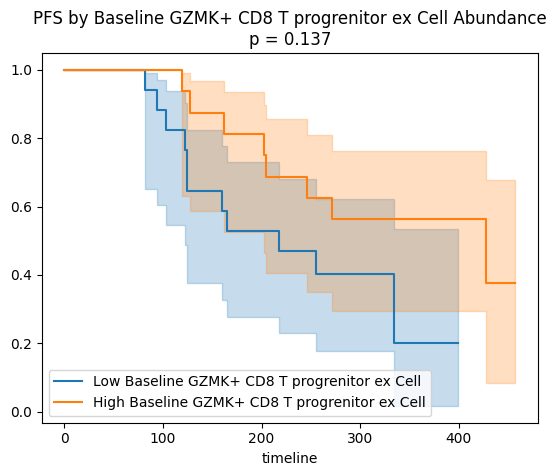

In [122]:
from lifelines import KaplanMeierFitter

temp_props = all_props[all_props['Timepoint'] == 'B']

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

T_A = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] <= temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['PFS']
E_A = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] <= temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['Censored PFS']
kmf_A.fit(T_A, E_A, label='Low Baseline GZMK+ CD8 T progrenitor ex Cell')
ax = kmf_A.plot_survival_function()

T_B = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] > temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['PFS']
E_B = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] > temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['Censored PFS']
kmf_B.fit(T_B, E_B, label='High Baseline GZMK+ CD8 T progrenitor ex Cell')
kmf_B.plot_survival_function(ax=ax)

results = logrank_test(
    durations_A=T_A,
    durations_B=T_B,
    event_observed_A=E_A,
    event_observed_B=E_B
)

plt.title(f"PFS by Baseline GZMK+ CD8 T progrenitor ex Cell Abundance\np = {round(results.p_value,3)}")
plt.show()

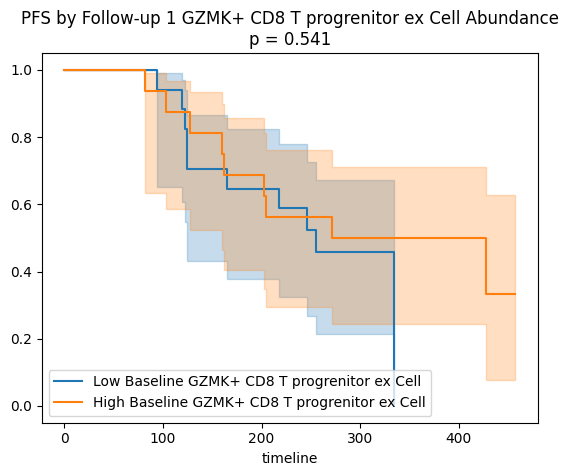

In [123]:
from lifelines import KaplanMeierFitter

temp_props = all_props[all_props['Timepoint'] == 'F1']

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

T_A = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] <= temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['PFS']
E_A = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] <= temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['Censored PFS']
kmf_A.fit(T_A, E_A, label='Low Baseline GZMK+ CD8 T progrenitor ex Cell')
ax = kmf_A.plot_survival_function()

T_B = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] > temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['PFS']
E_B = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] > temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['Censored PFS']
kmf_B.fit(T_B, E_B, label='High Baseline GZMK+ CD8 T progrenitor ex Cell')
kmf_B.plot_survival_function(ax=ax)

results = logrank_test(
    durations_A=T_A,
    durations_B=T_B,
    event_observed_A=E_A,
    event_observed_B=E_B
)

plt.title(f"PFS by Follow-up 1 GZMK+ CD8 T progrenitor ex Cell Abundance\np = {round(results.p_value,3)}")
plt.show()

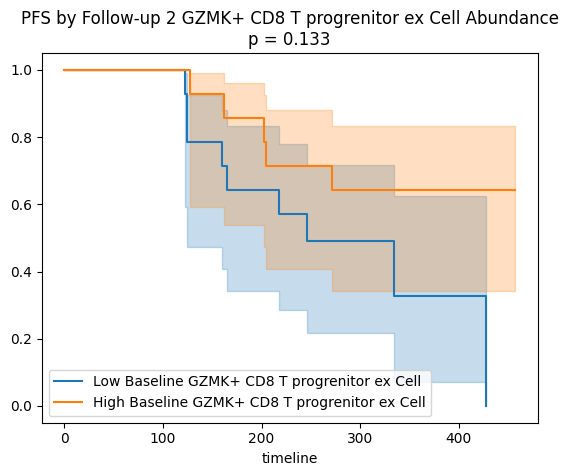

In [164]:
from lifelines import KaplanMeierFitter

temp_props = all_props[all_props['Timepoint'] == 'F2']

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

T_A = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] <= temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['PFS']
E_A = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] <= temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['Censored PFS']
kmf_A.fit(T_A, E_A, label='Low Baseline GZMK+ CD8 T progrenitor ex Cell')
ax = kmf_A.plot_survival_function()

T_B = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] > temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['PFS']
E_B = temp_props[temp_props['GZMK+ CD8 T progrenitor ex Cell'] > temp_props['GZMK+ CD8 T progrenitor ex Cell'].median()]['Censored PFS']
kmf_B.fit(T_B, E_B, label='High Baseline GZMK+ CD8 T progrenitor ex Cell')
kmf_B.plot_survival_function(ax=ax)

results = logrank_test(
    durations_A=T_A,
    durations_B=T_B,
    event_observed_A=E_A,
    event_observed_B=E_B
)

plt.title(f"PFS by Follow-up 2 GZMK+ CD8 T progrenitor ex Cell Abundance\np = {round(results.p_value,3)}")
plt.show()

In [127]:
tr_sharing = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/spectra_tr/tr_sharing.csv')

In [131]:
tr_sharing['patient'] = [i.split('_')[1] for i in tr_sharing['clonotype_patient']]

In [145]:
tr_sharing_pivot = tr_sharing[[
    'sharing_status','patient']].value_counts().reset_index().pivot(
    columns='sharing_status',index='patient',values=0
).fillna(0)
tr_sharing_pivot=tr_sharing_pivot.div(tr_sharing_pivot.sum(axis=1),axis=0)

In [147]:
tr_sharing_pivot['Proportion Shared'] = tr_sharing_pivot['All Timepoints Shared'] + tr_sharing_pivot['B-F1 Shared Only'] + tr_sharing_pivot['B-F2 Shared Only'] + tr_sharing_pivot['F1-F2 Shared Only']

In [150]:
her2_neg = pd.read_excel('/home/jupyter/data/ge_korea/raw_data/CAPOX-Pem_Patient_withTCGA.xlsx',sheet_name='HER2 Negative')
her2_neg = her2_neg[['Subject No','PFS','PD 0= no progression, 1= progression']].dropna()

In [151]:
her2_pos = pd.read_excel('/home/jupyter/data/ge_korea/raw_data/CAPOX-Pem_Patient_withTCGA.xlsx',sheet_name='HER2 Positive')
her2_pos = pd.concat([her2_pos[['Subject No']],
           pd.DataFrame({'PFS' : [314,314,82,124]}),
           her2_pos[['PD 0= no progression, 1= progression']]],axis=1)

In [152]:
meta = pd.concat([her2_neg,her2_pos]).reset_index(drop=True).sort_values('Subject No')

In [154]:
meta.index = meta['Subject No']

In [157]:
tr_sharing_pivot['PFS'] = tr_sharing_pivot.index.map(meta['PFS'].to_dict())

In [161]:
tr_sharing_pivot['Censored PFS'] = tr_sharing_pivot.index.map(meta['PD 0= no progression, 1= progression'].to_dict())

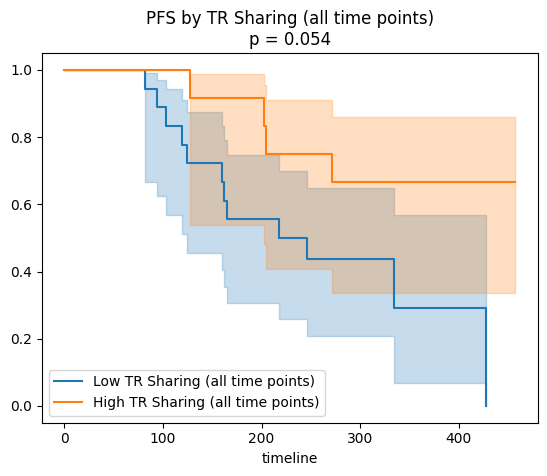

In [170]:
from lifelines import KaplanMeierFitter

temp_props = tr_sharing_pivot

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

T_A = temp_props[temp_props['All Timepoints Shared'] <= temp_props['All Timepoints Shared'].median()]['PFS']
E_A = temp_props[temp_props['All Timepoints Shared'] <= temp_props['All Timepoints Shared'].median()]['Censored PFS']
kmf_A.fit(T_A, E_A, label='Low TR Sharing (all time points)')
ax = kmf_A.plot_survival_function()

T_B = temp_props[temp_props['All Timepoints Shared'] > temp_props['All Timepoints Shared'].median()]['PFS']
E_B = temp_props[temp_props['All Timepoints Shared'] > temp_props['All Timepoints Shared'].median()]['Censored PFS']
kmf_B.fit(T_B, E_B, label='High TR Sharing (all time points)')
kmf_B.plot_survival_function(ax=ax)

results = logrank_test(
    durations_A=T_A,
    durations_B=T_B,
    event_observed_A=E_A,
    event_observed_B=E_B
)

plt.title(f"PFS by TR Sharing (all time points)\np = {round(results.p_value,3)}")
plt.show()

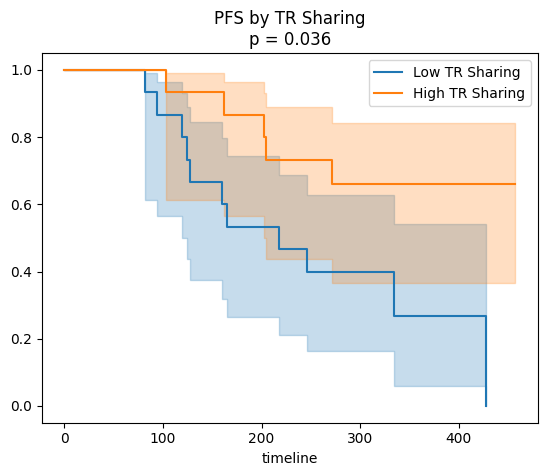

In [171]:
from lifelines import KaplanMeierFitter

temp_props = tr_sharing_pivot

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

T_A = temp_props[temp_props['Proportion Shared'] <= temp_props['Proportion Shared'].median()]['PFS']
E_A = temp_props[temp_props['Proportion Shared'] <= temp_props['Proportion Shared'].median()]['Censored PFS']
kmf_A.fit(T_A, E_A, label='Low TR Sharing')
ax = kmf_A.plot_survival_function()

T_B = temp_props[temp_props['Proportion Shared'] > temp_props['Proportion Shared'].median()]['PFS']
E_B = temp_props[temp_props['Proportion Shared'] > temp_props['Proportion Shared'].median()]['Censored PFS']
kmf_B.fit(T_B, E_B, label='High TR Sharing')
kmf_B.plot_survival_function(ax=ax)

results = logrank_test(
    durations_A=T_A,
    durations_B=T_B,
    event_observed_A=E_A,
    event_observed_B=E_B
)

plt.title(f"PFS by TR Sharing\np = {round(results.p_value,3)}")
plt.show()